# 3/3 — Validación: Métricas, Matrices y Grad-CAM
### Detección de Neumonía Bacteriana y Viral — Grupo 8

Tercer y último notebook de la serie. Carga el modelo entrenado por
**`02_Entrenamiento.ipynb`** y el CSV de test de **`01_Preprocesamiento.ipynb`**,
y genera todas las métricas, matrices de confusión y visualizaciones
Grad-CAM.

**Requisito:** haber corrido primero los notebooks 1 y 2 (deben existir los
`.csv` en `OUTPUT_DIR/data/` y al menos un archivo `.keras` en `OUTPUT_DIR`).


## 0. Configuración del entorno e instalación de librerías

In [ ]:
!pip install -q scikit-learn opencv-python-headless matplotlib seaborn tensorflow pandas


In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, multilabel_confusion_matrix

SEED = 42
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.10.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Cargar datos y modelo entrenado

Ajusta `OUTPUT_DIR` para que apunte a la MISMA carpeta usada en los
notebooks 1 y 2. Ajusta `MODEL_PATH` al archivo `.keras` que quieras
evaluar -- por defecto apunta al resultado de Focal Loss si existe, si no
al de fine-tuning, si no al de la fase 1 (ver la celda de confirmación al
final de `02_Entrenamiento.ipynb` para ver qué archivos tienes disponibles).


In [2]:
OUTPUT_DIR = './outputs'
DATA_DIR = os.path.join(OUTPUT_DIR, 'data')

assert os.path.isdir(DATA_DIR), (
    f"No se encontró '{DATA_DIR}'. Corre primero 01_Preprocesamiento.ipynb."
)

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_df.csv'))  # solo por si algo lo referencia
val_df = pd.read_csv(os.path.join(DATA_DIR, 'val_df.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_df.csv'))

with open(os.path.join(DATA_DIR, 'classes.txt')) as f:
    CLASSES = [line.strip() for line in f if line.strip()]

print(f"Test: {len(test_df)} imágenes | Clases: {CLASSES}")


Test: 586 imágenes | Clases: ['normal', 'bacteria', 'virus']


In [3]:
# Selección automática del mejor modelo disponible, en orden de preferencia
_candidates = [
    'modelo_densenet_focal.keras',
    'best_densenet_finetuned.keras',
    'best_densenet_model.keras',
]
MODEL_PATH = None
for _name in _candidates:
    _path = os.path.join(OUTPUT_DIR, _name)
    if os.path.isfile(_path):
        MODEL_PATH = _path
        break

if MODEL_PATH is None:
    raise FileNotFoundError(
        f"No se encontró ningún modelo .keras en {OUTPUT_DIR}. "
        f"Corre primero 02_Entrenamiento.ipynb, o ajusta MODEL_PATH manualmente."
    )

print("Modelo seleccionado:", MODEL_PATH)

# compile=False: solo vamos a hacer predict/evaluar, no a seguir entrenando,
# así evitamos depender de que Keras reconstruya el optimizador/loss
# personalizado (Focal Loss) al cargar desde disco.
model = keras.models.load_model(MODEL_PATH, compile=False)
model.summary()


Modelo seleccionado: ./outputs\modelo_densenet_focal.keras
Model: "densenet_pneumonia_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 gap (GlobalAveragePooling2D  (None, 1024)             0         
 )                                                               
                                                                 
 head_dense_128 (Dense)      (None, 128)               131200    
                                                                 
 head_batchnorm (BatchNormal  (None, 128)              512       
 ization)                                                        
                                            

In [4]:
def find_base_submodel(loaded_model):
    """
    Encuentra el sub-modelo base (DenseNet121/MobileNetV2) dentro del
    modelo cargado desde disco. Como el modelo se guardó y recargó, ya no
    tenemos la referencia directa en Python a `base_model` como en el
    notebook de entrenamiento -- la recuperamos por tipo de capa (buscamos
    la capa que es en sí misma otro modelo de Keras), de forma explícita
    y verificable, sin adivinar nombres.
    """
    for layer in loaded_model.layers:
        if isinstance(layer, keras.Model):
            return layer
    raise ValueError("No se encontró un submodelo base dentro del modelo cargado.")

base_model = find_base_submodel(model)
print("Submodelo base encontrado:", base_model.name)


Submodelo base encontrado: densenet121


## 2. Reconstrucción del pipeline de datos de test

Mismo preprocesamiento (resize 224×224, normalización) que en el
entrenamiento -- SIN augmentation, ya que es test.


In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

def load_and_preprocess(filepath, label_idx, augment=False):
    raw = tf.io.read_file(filepath)
    img = tf.io.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = img / 255.0
    img = tf.clip_by_value(img, 0.0, 1.0)
    label_onehot = tf.one_hot(label_idx, depth=len(CLASSES))
    return img, label_onehot

def make_dataset(df, shuffle=False):
    filepaths = df['filepath'].values
    label_idxs = df['label'].map(CLASS_TO_IDX).values.astype('int32')
    ds = tf.data.Dataset.from_tensor_slices((filepaths, label_idxs))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(lambda fp, lb: load_and_preprocess(fp, lb), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

test_ds = make_dataset(test_df, shuffle=False)
print("Pipeline de test listo.")


Pipeline de test listo.


## 3. Evaluación (CU-02 / HU-03, HU-04)

In [6]:
y_true = test_df['label'].map(CLASS_TO_IDX).values

y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Exactitud general:", (y_pred == y_true).mean())
print()
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))


19/19 [==============================] - 6s 203ms/step
Exactitud general: 0.7969283276450512

              precision    recall  f1-score   support

      normal      0.886     0.987     0.934       158
    bacteria      0.852     0.745     0.795       278
       virus      0.623     0.693     0.656       150

    accuracy                          0.797       586
   macro avg      0.787     0.808     0.795       586
weighted avg      0.803     0.797     0.797       586



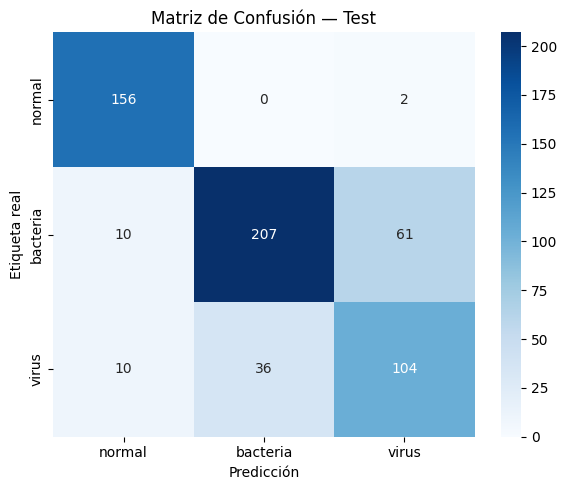

% de bacteriana clasificada como viral: 21.94%
% de viral clasificada como bacteriana: 24.00%


In [7]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de Confusión — Test')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'matriz_confusion.png'), dpi=150)
plt.show()

# Tasa de error específica viral <-> bacteriana (interés particular del proyecto, sección 6)
idx_bact = CLASSES.index('bacteria')
idx_virus = CLASSES.index('virus')
bact_as_virus = cm[idx_bact, idx_virus] / cm[idx_bact].sum()
virus_as_bact = cm[idx_virus, idx_bact] / cm[idx_virus].sum()
print(f"% de bacteriana clasificada como viral: {bact_as_virus*100:.2f}%")
print(f"% de viral clasificada como bacteriana: {virus_as_bact*100:.2f}%")


### 3.1 Matrices de confusión One-vs-Rest (por clase)

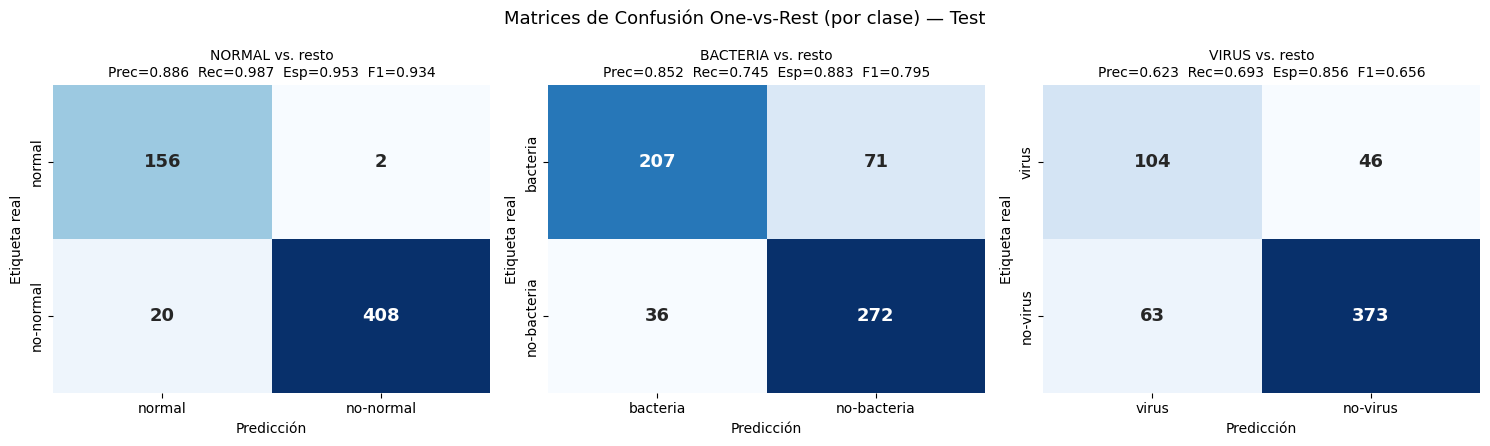

,clase,TP,FP,TN,FN,precision,recall_sensibilidad,especificidad,f1
0,normal,156,20,408,2,0.886364,0.987342,0.953271,0.934132
1,bacteria,207,36,272,71,0.851852,0.744604,0.883117,0.794626
2,virus,104,63,373,46,0.622754,0.693333,0.855505,0.656151


In [8]:
from sklearn.metrics import multilabel_confusion_matrix

# multilabel_confusion_matrix con labels=[0,1,2] devuelve, para cada clase i,
# una matriz 2x2 en el orden [[TN, FP], [FN, TP]] -- exactamente el resultado
# de tratar la clase i como "positiva" y todas las demás como "negativa".
mcm = multilabel_confusion_matrix(y_true, y_pred, labels=range(len(CLASSES)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ovr_metrics = []

for i, (cls, ax) in enumerate(zip(CLASSES, axes)):
    tn, fp, fn, tp = mcm[i].ravel()

    # Métricas calculadas directamente de TN/FP/FN/TP (verificables a mano)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0          # sensibilidad
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0.0)

    ovr_metrics.append({
        'clase': cls, 'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'precision': precision, 'recall_sensibilidad': recall,
        'especificidad': specificity, 'f1': f1,
    })

    matriz_2x2 = np.array([[tp, fn],
                            [fp, tn]])
    sns.heatmap(
        matriz_2x2, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
        xticklabels=[f'{cls}', f'no-{cls}'],
        yticklabels=[f'{cls}', f'no-{cls}'],
        annot_kws={'size': 13, 'fontweight': 'bold'},
    )
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Etiqueta real')
    ax.set_title(f'{cls.upper()} vs. resto\n'
                  f'Prec={precision:.3f}  Rec={recall:.3f}  '
                  f'Esp={specificity:.3f}  F1={f1:.3f}',
                  fontsize=10)

plt.suptitle('Matrices de Confusión One-vs-Rest (por clase) — Test', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'matrices_confusion_one_vs_rest.png'), dpi=150)
plt.show()

ovr_df = pd.DataFrame(ovr_metrics)
ovr_df.to_csv(os.path.join(OUTPUT_DIR, 'metricas_one_vs_rest.csv'), index=False)
ovr_df


In [9]:
# Reporte de inferencia en CSV (producto tangible)
report_df = pd.DataFrame({
    'filepath': test_df['filepath'].values,
    'archivo': [os.path.basename(p) for p in test_df['filepath'].values],
    'etiqueta_real': [CLASSES[i] for i in y_true],
    'prediccion': [CLASSES[i] for i in y_pred],
    'prob_normal': y_pred_probs[:, CLASSES.index('normal')],
    'prob_bacteria': y_pred_probs[:, CLASSES.index('bacteria')],
    'prob_virus': y_pred_probs[:, CLASSES.index('virus')],
})
report_df.to_csv(os.path.join(OUTPUT_DIR, 'reporte_inferencia.csv'), index=False)
report_df.head()


,filepath,archivo,etiqueta_real,prediccion,prob_normal,prob_bacteria,prob_virus
0,D:\Escritorio\Espol\IA\chest_xray\train\PNEUMO...,person498_bacteria_2100.jpeg,bacteria,normal,0.980709,0.010703,8.588829e-03
1,D:\Escritorio\Espol\IA\chest_xray\test\PNEUMON...,person175_bacteria_835.jpeg,bacteria,bacteria,0.005923,0.571443,4.226343e-01
2,D:\Escritorio\Espol\IA\chest_xray\train\PNEUMO...,person326_bacteria_1504.jpeg,bacteria,virus,0.118980,0.388776,4.922441e-01
3,D:\Escritorio\Espol\IA\chest_xray\train\PNEUMO...,person1067_virus_1770.jpeg,virus,virus,0.024079,0.135740,8.401811e-01
4,D:\Escritorio\Espol\IA\chest_xray\train\NORMAL...,IM-0707-0001.jpeg,normal,normal,0.999997,0.000003,4.056328e-07


### 3.2 Curvas ROC-AUC (One-vs-Rest, por clase)

Como es un problema de 3 clases, se genera una curva ROC por clase usando
el mismo enfoque One-vs-Rest de la sección anterior: cada clase se trata
como "positiva" contra el resto. Cada curva grafica, para distintos
umbrales de decisión, la **Tasa de Verdaderos Positivos (Recall)** contra
la **Tasa de Falsos Positivos**, y el **AUC** (área bajo la curva) resume
en un solo número qué tan bien esa clase se separa del resto —
1.0 es perfecto, 0.5 es equivalente a adivinar al azar.

Se usan las probabilidades (`y_pred_probs`) que ya calculó el modelo en la
sección 3, no hace falta volver a correr `model.predict()`.


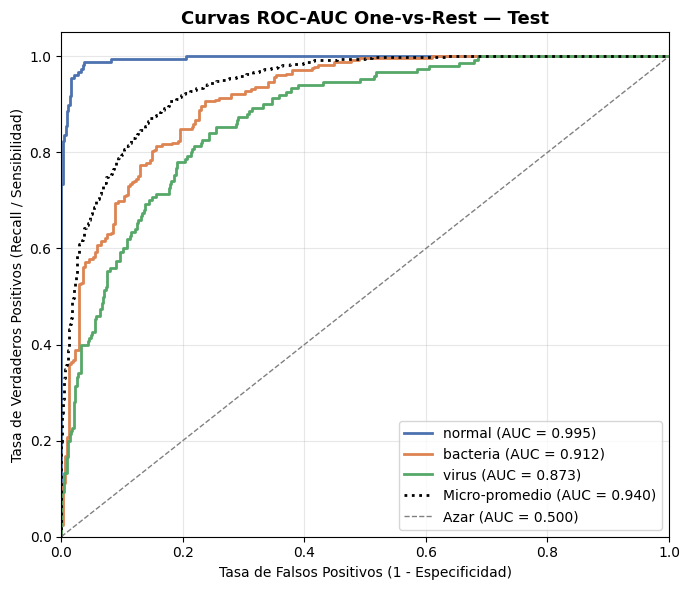

AUC por clase:
      normal: 0.995
    bacteria: 0.912
       virus: 0.873
   micro-avg: 0.940


In [10]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Convertir y_true (enteros 0/1/2) a formato one-hot para calcular ROC
# One-vs-Rest por clase.
y_true_onehot = label_binarize(y_true, classes=range(len(CLASSES)))

fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Curva ROC "micro-promedio": trata todas las predicciones de todas las
# clases como un solo problema binario grande -- da una visión global,
# complementaria a las curvas por clase.
fpr['micro'], tpr['micro'], _ = roc_curve(y_true_onehot.ravel(), y_pred_probs.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

# --- Gráfico ---
plt.figure(figsize=(7, 6))
colors = cycle(['#4C72B0', '#DD8452', '#55A868'])

for i, (cls, color) in enumerate(zip(CLASSES, colors)):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
              label=f'{cls} (AUC = {roc_auc[i]:.3f})')

plt.plot(fpr['micro'], tpr['micro'], color='black', linestyle=':', lw=2,
          label=f'Micro-promedio (AUC = {roc_auc["micro"]:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Azar (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall / Sensibilidad)')
plt.title('Curvas ROC-AUC One-vs-Rest — Test', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'curvas_roc_auc.png'), dpi=150)
plt.show()

print("AUC por clase:")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:>10}: {roc_auc[i]:.3f}")
print(f"  {'micro-avg':>10}: {roc_auc['micro']:.3f}")


## 8. Explicabilidad visual — Grad-CAM (CU-03 / HU-05, HU-06)

Genera mapas de calor sobre el mapa de características final para auditar qué
regiones de la radiografía influyeron en la predicción.

**Sin caja negra**: usamos directamente `base_model.output` — el mapa de
activaciones COMPLETO justo antes del Global Average Pooling, en vez de
buscar "alguna capa convolucional" que podría estar incompleta (p. ej. una
capa intermedia de 32 canales dentro del último bloque de DenseNet, en vez
del mapa completo de 1024 canales). Esto da heatmaps más precisos y evita
que se dispersen hacia zonas fuera del pulmón. Luego reaplicamos las capas
REALES y ya entrenadas de la cabecera (mismos objetos, mismos pesos) por
nombre — nada se reconstruye ni se redefine.


In [11]:
# En vez de buscar "la última capa Conv2D" (lo cual en DenseNet121 puede
# agarrar una capa intermedia de solo 32 canales, dentro del último bloque,
# NO el mapa de características completo), usamos directamente la salida de
# `base_model`: es el mapa de activaciones final y completo (1024 canales en
# DenseNet121 / 1280 en MobileNetV2), justo antes del Global Average Pooling
# — literalmente la información que el modelo usa para decidir. Esto da
# heatmaps mucho más precisos y menos dispersos hacia zonas irrelevantes.
print("Base model:", base_model.name)
print("Forma de salida de base_model (mapa de características final):", base_model.output_shape)


Base model: densenet121
Forma de salida de base_model (mapa de características final): (None, 7, 7, 1024)


In [12]:
# grad_conv_model: usa base_model.input como entrada (grafo autocontenido y
# válido) y produce directamente base_model.output — el mapa de
# características COMPLETO antes del pooling. Luego reaplicamos las capas
# REALES y ya entrenadas de la cabecera (mismos objetos, mismos pesos) por
# nombre, en el mismo orden que build_model(). No se reconstruye ni redefine
# ninguna capa.

grad_conv_model = keras.Model(
    inputs=base_model.input,
    outputs=base_model.output,
)

def make_gradcam_heatmap(img_array, pred_index=None):
    """img_array: tensor [1, 224, 224, 3] ya normalizado (mismo preprocesamiento que en entrenamiento)."""
    with tf.GradientTape() as tape:
        conv_outputs = grad_conv_model(img_array, training=False)
        tape.watch(conv_outputs)

        # Reaplicamos las capas REALES de la cabecera (mismos objetos, mismos
        # pesos entrenados) por nombre, en el mismo orden que en build_model().
        x = model.get_layer('gap')(conv_outputs)
        x = model.get_layer('head_dense_128')(x)
        x = model.get_layer('head_batchnorm')(x, training=False)
        x = model.get_layer('head_dropout')(x, training=False)
        preds = model.get_layer('predictions')(x)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradiente de la clase predicha respecto al mapa de características completo
    grads = tape.gradient(class_channel, conv_outputs)
    # Promedio espacial de los gradientes -> importancia de cada canal/filtro
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs_single = conv_outputs[0]
    heatmap = conv_outputs_single @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index), preds.numpy()[0]

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(heatmap_colored, alpha, img, 1 - alpha, 0)
    return overlay


In [13]:
# Verificación de coherencia: las probabilidades que devuelve grad_model deben
# ser IDÉNTICAS a las de model.predict(), ya que es el mismo grafo. Esto confirma
# que no estamos reconstruyendo nada distinto al modelo real.
_check_img_path = test_df.iloc[0]['filepath']
_check_img, _ = load_and_preprocess(_check_img_path, 0, augment=False)
_check_img = tf.expand_dims(_check_img, axis=0)

_, _, probs_from_gradmodel = make_gradcam_heatmap(_check_img)
probs_from_model = model.predict(_check_img, verbose=0)[0]

print("Probabilidades (grad_model):", np.round(probs_from_gradmodel, 4))
print("Probabilidades (model.predict):", np.round(probs_from_model, 4))
print("¿Coinciden?", np.allclose(probs_from_gradmodel, probs_from_model, atol=1e-5))


Probabilidades (grad_model): [0.9807 0.0107 0.0086]
Probabilidades (model.predict): [0.9807 0.0107 0.0086]
¿Coinciden? True


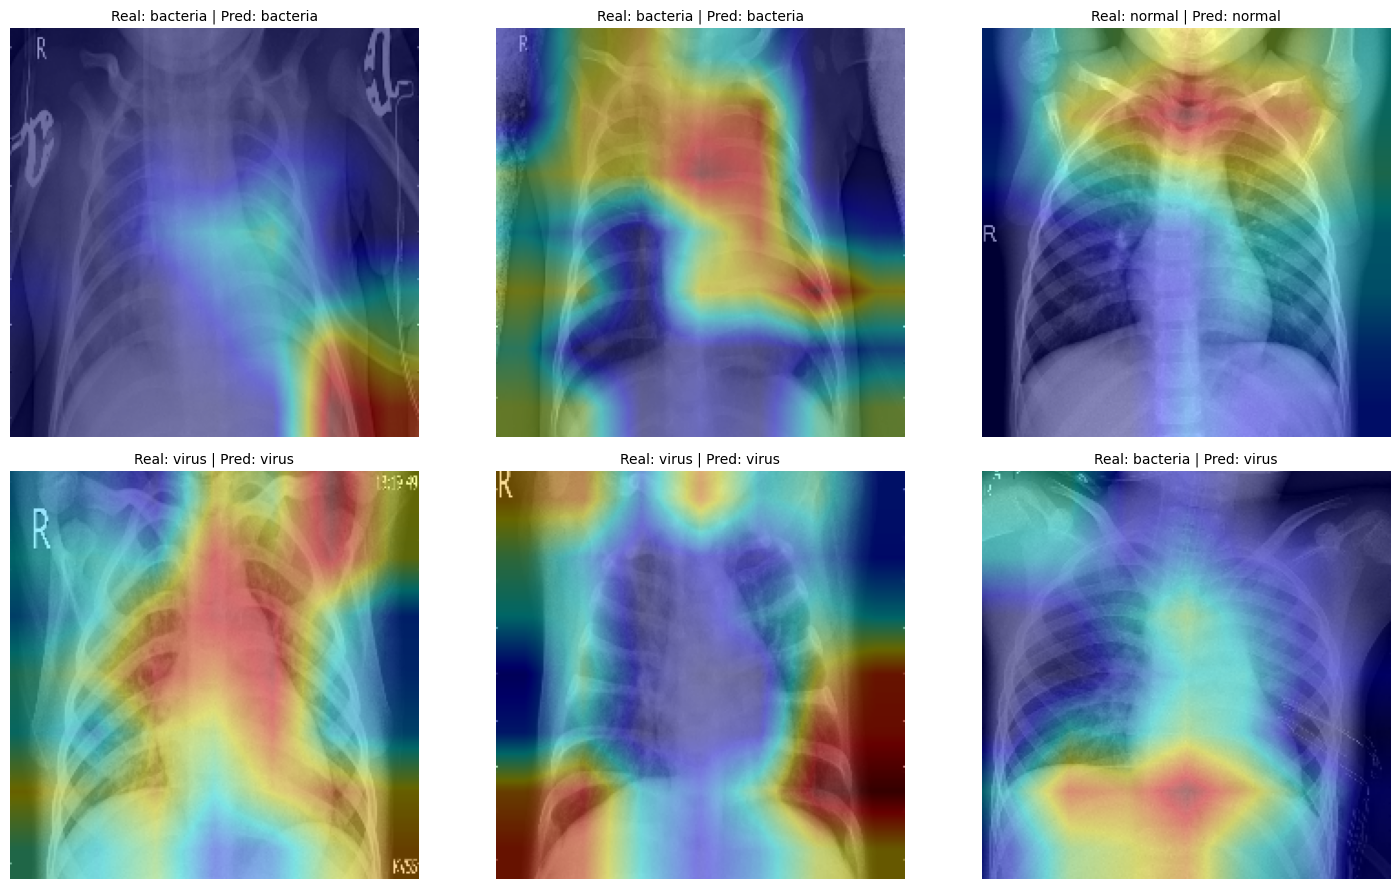

In [14]:
sample_rows = report_df.sample(6, random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (_, row) in zip(axes.flatten(), sample_rows.iterrows()):
    img_path = row['filepath']
    img_tensor, _ = load_and_preprocess(img_path, 0, augment=False)
    img_array = tf.expand_dims(img_tensor, axis=0)

    heatmap, pred_idx, _ = make_gradcam_heatmap(img_array)
    overlay = overlay_gradcam(img_path, heatmap)

    ax.imshow(overlay)
    ax.set_title(f"Real: {row['etiqueta_real']} | Pred: {CLASSES[pred_idx]}", fontsize=10)
    ax.axis('off')

    out_name = os.path.join(OUTPUT_DIR, "gradcam_outputs", f"{row['archivo']}_gradcam.png")
    plt.imsave(out_name, overlay)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gradcam_grid.png'), dpi=150)
plt.show()


## 4. Resumen de archivos generados

Todo quedó guardado en `OUTPUT_DIR`:
- `matriz_confusion.png`, `matrices_confusion_one_vs_rest.png`
- `reporte_inferencia.csv`, `metricas_one_vs_rest.csv`
- `gradcam_outputs/` (mapas de calor individuales), `gradcam_grid.png`

El modelo en sí (`.keras`) ya estaba guardado desde `02_Entrenamiento.ipynb`
-- este notebook no lo vuelve a guardar, solo lo carga y lo evalúa.


In [15]:
print("Archivos generados en", OUTPUT_DIR, ":\n")
for f in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(path):
        print(" ", f)


Archivos generados en ./outputs :

  best_densenet_finetuned.keras
  best_densenet_model.keras
  curvas_entrenamiento.png
  curvas_finetuning.png
  curvas_focal_loss.png
  curvas_roc_auc.png
  distribucion_clases.png
  distribucion_clases_por_split.png
  gradcam_grid.png
  matrices_confusion_one_vs_rest.png
  matriz_confusion.png
  metricas_one_vs_rest.csv
  modelo_densenet_focal.keras
  reporte_inferencia.csv
